# Introducción al aprendizaje automatizado (O2026)

## Tutorial 5. Parte 1. Regresion lineal

**Objetivo:** Correr regresiones lineales. Estimar polinomios y encontrar el ECM.

Veremos:
- Repaso de Numpy y Scikit-learn
- Regresión lineal simple y múltiple
- Estadísticas (similares a stata o R) con nuevo módulo 
- Estimar el ECM (o MSE), RMSE, y MAE

##  Repaso: NumPy y scikit-learn                   
**El paquete NumPy** es fundamental en Python. Está escrito en lenguajes de bajo nivel, lo que permite realizar operaciones matemáticas de manera muy eficiente. Para más información, ver la [guía oficial de uso de NumPy](https://docs.scipy.org/doc/numpy/user/index.html).

**El paquete scikit-learn** es una biblioteca de Python usada para machine learning, construida encima de NumPy y otros paquetes. Permite procesar datos, reducir la dimensionalidad de la base, implementar regresiones, clasificaciones, clustering y más. Pueden ver la [web de scikit-learn](https://scikit-learn.org/stable/)


In [1]:
# Importamos paquetes
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
# Correr si les tira que necesitan la ultima version de pandas. 
#En caso de necesitar el update de pandas
#import sys
#!{sys.executable} -m pip install --upgrade pandas

In [ ]:
# Instalar modulo de statsmodels 
#!pip install statsmodels

## Regresión Simple
Sea el modelo de regresión simple con un predictores ($p=1$):
$$
y_i = \beta_0 + \beta_1 \times x_{1i}  + \epsilon
$$
donde $\epsilon$ es el error no sistemático del modelo.

In [2]:
# Creamos unos datos de ejemplo
x = np.array([5, 15, 25, 35, 45, 55]) # Predictor
y = np.array([5, 20, 14, 32, 22, 38]) # Variable de interés a predecir

print(x)
print(y)
# Ambos son vectores fila

[ 5 15 25 35 45 55]
[ 5 20 14 32 22 38]


In [3]:
# Repasamos el Reshape para transformar x en un vector columna
x = x.reshape((-1, 1))   # El -1 indica el largo del array; n=6 observaciones, k=1 caracteristicas

print(x)
print(y) 

[[ 5]
 [15]
 [25]
 [35]
 [45]
 [55]]
[ 5 20 14 32 22 38]


### Regresión lineal con skit-learn
Ahora utilizaremos la función [LinearRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) del paquete scikit-learn.
    
Se pueden proveer muchos parámetros opcionales para esta función:

- **fit_intercept**: Booleano que decide si calcular el intercepto (True) o considerarlo igual a cero (False) ($\beta_0$). Por default es True.
- **normalize**: Booleano que decide si normalizar las variables input (True) o no (False). Es False por default.
- **copy_X**: Booleano que decide si copiar (True) o sobreescribir las variables input (False). Es True por default.

In [4]:
# Primero, estimar el modelo. Lo hacemos con fit():
model = LinearRegression().fit(x, y) #fit_intercept=True

In [5]:
# Veamos ahora los resultados por MCO

# Calculamos el R2
r2 = model.score(x, y)
print('Coeficiente de determinación:', r2)

# El intercepto
intercepto = model.intercept_
print('\nIntercepto:', intercepto)

# La pendiente
pendiente = model.coef_
print('\nPendiente:', pendiente)


Coeficiente de determinación: 0.7158756137479542

Intercepto: 5.633333333333329

Pendiente: [0.54]


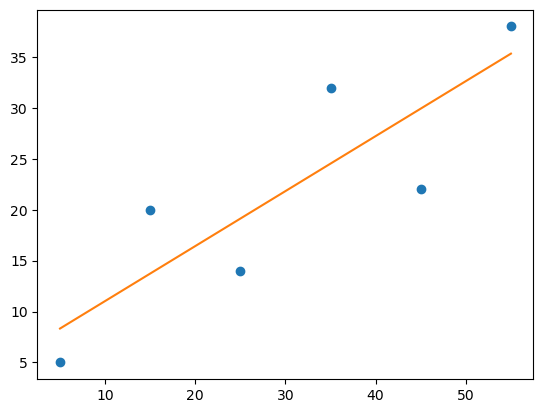

In [6]:
# Hacemos un scatter plot
plt.plot(x, y, 'o')
plt.plot(x, pendiente*x + intercepto)


Supongamos que ahora queremos predecir con este modelo $\hat{Y}$. Para ellos, usamos la funcion de `.predict()`y los valores del regresor en el modelo estimado y obtenemos la correspondiente respuesta predicha $\hat{Y}$.

In [7]:
# Predicción Y_hat
y_pred = model.predict(x)
print('Respuesta predicha:\n', y_pred)

# Recordemos cómo era nuestro vector y
print('\nEl vector de y:', y)

# Recordemos cómo era nuestro vector x
print('\nEl vector de x:', x)



Respuesta predicha:
 [ 8.33333333 13.73333333 19.13333333 24.53333333 29.93333333 35.33333333]

El vector de y: [ 5 20 14 32 22 38]

El vector de x: [[ 5]
 [15]
 [25]
 [35]
 [45]
 [55]]


#### Precisión del modelo
Recordamos que definimos el $R^2$ como:
$$
R^2 = \frac{TSS-RSS}{TSS} = 1- \frac{RSS}{TSS}
$$
donde $TSS= \Sigma (y_i - \bar{y} )^2$ y $RSS=\Sigma (y_i - \hat{y} )^2$

In [8]:
# Calculamos el R2 (Alternativa 1)
r2 = model.score(x, y)
print('Coeficiente de determinación:', r2)

# Con la y predicha podemos calcular el R^2 de esta otra forma (Alternativa 2)
r2_new = r2_score(y, y_pred)
print("\nResultado alternativo para R2:", r2_new)

Coeficiente de determinación: 0.7158756137479542

Resultado alternativo para R2: 0.7158756137479542


#### Predicción Afuera de la Muestra
Supongamos tenemos nuevos datos y queremos ver qué tan buenos somos para predecir con los nuevos datos

In [9]:
# Si quiero probar valores nuevos de x (no los que usé para estimar el modelo):
x_new = np.arange(start=10, stop=20, step=2).reshape((-1, 1))   # arrange: crea una secuencia de numeros. 
                                                                # Generamos valores entre [10, 20), con saltos de 2 en 2
print(x_new)

y_pred_new = model.predict(x_new)
print('\nNueva respuesta predicha:\n', y_pred_new)

[[10]
 [12]
 [14]
 [16]
 [18]]

Nueva respuesta predicha:
 [11.03333333 12.11333333 13.19333333 14.27333333 15.35333333]


## Regresión Multiple
Sea el modelo de regresión múltiple con dos predictores ($p=2$):
$$
y_i = \beta_0 + \beta_1 \times x_{1i} + \beta_2 \times x_{2i} + \epsilon
$$

In [11]:
# Armamos un vector para la variable dependiente y una matriz de regresores:
x = np.array([[0, 1], [5, 1], [15, 2], [25, 5], [35, 11], [45, 15], [55, 34], [60, 35]])

y =  np.array([4, 5, 20, 14, 32, 22, 38, 43])

print(x)
print(y)


[[ 0  1]
 [ 5  1]
 [15  2]
 [25  5]
 [35 11]
 [45 15]
 [55 34]
 [60 35]]
[ 4  5 20 14 32 22 38 43]


In [12]:
# Estimamos el modelo
model = LinearRegression().fit(x, y)
r2 = model.score(x, y)

# Miramos resultados
print('Coeficiente de determinación:', r2)
print('\nIntercepto:', model.intercept_)
print('\nCoeficientes:', model.coef_)

Coeficiente de determinación: 0.8615939258756776

Intercepto: 5.522579275198183

Coeficientes: [0.44706965 0.25502548]


In [15]:
# Vemos la respuesta predicha para los valores originales de los regresores
y_pred = model.predict(x)
print('Respuesta predicha:', y_pred, sep='\n')

Respuesta predicha:
[ 5.77760476  8.012953   12.73867497 17.9744479  23.97529728 29.4660957
 38.78227633 41.27265006]


In [16]:
# Vemos la predicción para nuevos valores de X
x_new = np.arange(start=1, stop=31, step=3).reshape((-1, 2))   # Matriz con 2 columnas y tantas filas como tenga el array
print(x_new)
y_new = model.predict(x_new)
print('Nueva respuesta predicha:', y_new, sep='\n')

[[ 1  4]
 [ 7 10]
 [13 16]
 [19 22]
 [25 28]]
Nueva respuesta predicha:
[ 6.98975085 11.20232163 15.41489241 19.62746319 23.84003398]


### REGRESIÓN POLINÓMICA
Si queremos correr una regresión de y contra x y x^2 necesitamos generar los datos de la nueva variable independiente.

[PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) (de scikitlearn) genera una nueva matriz que consta de todas las combinaciones polinomiales de las x con un grado menor o igual al grado especificado. Por ejemplo, si una muestra de entrada es bidimensional y de la forma [a, b], las características polinomiales de grado 2 son [1, a, b, a^2, ab, b^2].

Se pueden cambiar varios parámetros de PolynomialFeatures:

- **degree** es un entero (2 por default) que representa el grado de la función de regresión polinómica.

- **include_bias** es un Booleano (True por default) que decide si incluir la columna de 1 que corresponde al intercepto (True) o no (False).


In [17]:
x = np.array([5, 15, 25, 35, 45, 55]).reshape((-1, 1))   # ¿Por qué reshape?
y = np.array([15, 11, 2, 8, 25, 32])   # Vector fila
print(x)
print(y)

[[ 5]
 [15]
 [25]
 [35]
 [45]
 [55]]
[15 11  2  8 25 32]


In [18]:
model_pol = PolynomialFeatures(degree = 2, include_bias=False)
model_pol.fit(x)
x_ = model_pol.transform(x)   # Aplicamos transformación a los datos. Genera una matriz de 6x2 (con x y x^2)
# equivalente a: x_ = model_pol.fit_transform(x)
print(x_)

[[   5.   25.]
 [  15.  225.]
 [  25.  625.]
 [  35. 1225.]
 [  45. 2025.]
 [  55. 3025.]]


In [19]:
# Ahora usamos x_ para correr la regresión
model_pol = LinearRegression().fit(x_, y)

In [20]:
print('Coeficiente de determinación:', model_pol.score(x_, y))
print('\nIntercepto:', model_pol.intercept_)
print('\nCoeficientes:', model_pol.coef_)

Coeficiente de determinación: 0.8908516262498564

Intercepto: 21.37232142857143

Coeficientes: [-1.32357143  0.02839286]


### Imitando a Stata con statsmodels

[statsmodels](https://www.statsmodels.org/stable/index.html) proporciona clases y funciones para la estimación de modelos estadísticos, para realizar pruebas estadísticas y para explorar datos estadísticos.
Ventaja: ouput similar a stata

In [21]:
x = [[0, 1], [5, 1], [15, 2], [25, 5], [35, 11], [45, 15], [55, 34], [60, 35]]
y = [4, 5, 20, 14, 32, 22, 38, 43]
x, y = np.array(x), np.array(y)

x = sm.add_constant(x)
print(x)
print(y)

[[ 1.  0.  1.]
 [ 1.  5.  1.]
 [ 1. 15.  2.]
 [ 1. 25.  5.]
 [ 1. 35. 11.]
 [ 1. 45. 15.]
 [ 1. 55. 34.]
 [ 1. 60. 35.]]
[ 4  5 20 14 32 22 38 43]


In [22]:
# Especificamos el modelo
model = sm.OLS(y, x)
# Ajustamos el modelo
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     15.56
Date:                Tue, 07 Apr 2026   Prob (F-statistic):            0.00713
Time:                        15:11:06   Log-Likelihood:                -24.316
No. Observations:                   8   AIC:                             54.63
Df Residuals:                       5   BIC:                             54.87
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5226      4.431      1.246      0.2

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [23]:
# Si solo queremos ver los coeficientes
print(results.params)

[5.52257928 0.44706965 0.25502548]


In [24]:
import os

In [25]:
os.getcwd()

'/Users/lucianaazulramirez/Desktop/Pre-Doc/Big Data/E337_Big_Data_UdeSA/Tutorial 5'

In [27]:
results.summary().as_csv()

'                      OLS Regression Results                     \nDep. Variable:   ,y               ,  R-squared:         ,   0.862\nModel:           ,OLS             ,  Adj. R-squared:    ,   0.806\nMethod:          ,Least Squares   ,  F-statistic:       ,   15.56\nDate:            ,Tue, 07 Apr 2026,  Prob (F-statistic):,0.00713 \nTime:            ,15:14:39        ,  Log-Likelihood:    , -24.316\nNo. Observations:,     8          ,  AIC:               ,   54.63\nDf Residuals:    ,     5          ,  BIC:               ,   54.87\nDf Model:        ,     2          ,                     ,        \nCovariance Type: ,nonrobust       ,                     ,        \n     ,   coef   , std err ,    t    ,P>|t| ,  [0.025 ,  0.975] \nconst,    5.5226,    4.431,    1.246, 0.268,   -5.867,   16.912\nx1   ,    0.4471,    0.285,    1.567, 0.178,   -0.286,    1.180\nx2   ,    0.2550,    0.453,    0.563, 0.598,   -0.910,    1.420\nOmnibus:      , 0.561,  Durbin-Watson:     ,   3.268\nProb(Omnibus):,

Se puede obtener la respuesta predicha con los valores de x para estimar el modelo con `.predict()` o `.fittedvalues`:

In [28]:
print('predicted response:\n', results.predict(x)) 

predicted response:
 [ 5.77760476  8.012953   12.73867497 17.9744479  23.97529728 29.4660957
 38.78227633 41.27265006]


In [29]:
print('predicted response:\n', results.fittedvalues) #equivalente: results.predict(x)

predicted response:
 [ 5.77760476  8.012953   12.73867497 17.9744479  23.97529728 29.4660957
 38.78227633 41.27265006]


##   Metricas de Desempeño en Regresión

Ahora veamos algunas métricas de evaluación usuales para los problemas de regresión en Machine Learning.

Vamos a observar los valores de las siguientes métricas:

**Promedio de la Suma de Residuos/Errores al Cuadrado / Mean Squared Error** No confundir con la traduccion literal "error cuadratico medio"

$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{f}(x_i))^2$

Mide el error promedio, pero castigando mucho más los errores grandes.

**Raíz del Error Cuadrático Medio / Root Mean Squared Error**

$RMSE = \sqrt{MSE}$

vuelve a estar en las mismas unidades que la variable y

**Error Absoluto Medio / Mean Absolute Error**

$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{f}(x_i)|$

Mide cuánto se equivoca el modelo en promedio, sin elevar al cuadrado y por lo tanto no penaliza errores mas grandes. 

In [30]:
# Generamos un dataset aleatorio
np.random.seed(0)
x = np.random.rand(100)  # Array de la forma (100, 1) con nros aleatorios entre [0, 1) de una distribución uniforme
epsilon = np.random.normal(0,1,100) # media 0 y sd 1, no sistematico

y = 2 + 3*x + epsilon
print("x:\n", x)
print("y:\n", y)
print("epsilon:\n", epsilon)

x:
 [0.5488135  0.71518937 0.60276338 0.54488318 0.4236548  0.64589411
 0.43758721 0.891773   0.96366276 0.38344152 0.79172504 0.52889492
 0.56804456 0.92559664 0.07103606 0.0871293  0.0202184  0.83261985
 0.77815675 0.87001215 0.97861834 0.79915856 0.46147936 0.78052918
 0.11827443 0.63992102 0.14335329 0.94466892 0.52184832 0.41466194
 0.26455561 0.77423369 0.45615033 0.56843395 0.0187898  0.6176355
 0.61209572 0.616934   0.94374808 0.6818203  0.3595079  0.43703195
 0.6976312  0.06022547 0.66676672 0.67063787 0.21038256 0.1289263
 0.31542835 0.36371077 0.57019677 0.43860151 0.98837384 0.10204481
 0.20887676 0.16130952 0.65310833 0.2532916  0.46631077 0.24442559
 0.15896958 0.11037514 0.65632959 0.13818295 0.19658236 0.36872517
 0.82099323 0.09710128 0.83794491 0.09609841 0.97645947 0.4686512
 0.97676109 0.60484552 0.73926358 0.03918779 0.28280696 0.12019656
 0.2961402  0.11872772 0.31798318 0.41426299 0.0641475  0.69247212
 0.56660145 0.26538949 0.52324805 0.09394051 0.5759465  0.929

In [31]:
print("Forma de x:", x.shape) #cantidad de elementos
print("Forma de y:", y.shape)

print("Dimensiones de x:", x.ndim) #dirección
print("Dimensiones de y:", y.ndim)

Forma de x: (100,)
Forma de y: (100,)
Dimensiones de x: 1
Dimensiones de y: 1


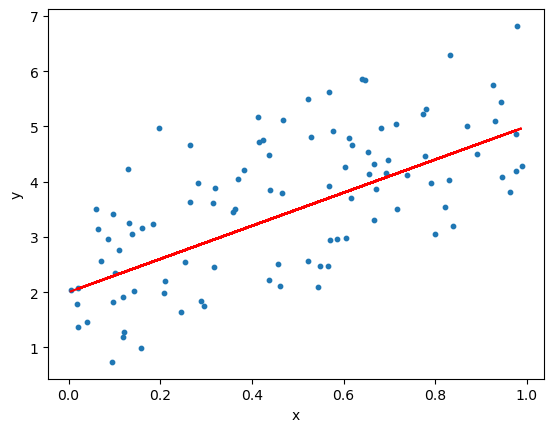

In [32]:
# Graficamos
plt.scatter(x, y, s=10)  # s = tamaño de los puntos del scatter.
plt.plot(x, 2+3*x, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [33]:
x_con = sm.add_constant(x)
model = sm.OLS(y, x_con)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                     70.80
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           3.29e-13
Time:                        15:34:17   Log-Likelihood:                -141.51
No. Observations:                 100   AIC:                             287.0
Df Residuals:                      98   BIC:                             292.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2222      0.193     11.496      0.0

In [34]:
# Predecimos las y
y_pred = results.predict(x_con)
y_pred

print("Forma de y_pred:", y_pred.shape)
print("Dimensiones de y:", y_pred.ndim)

Forma de y_pred: (100,)
Dimensiones de y: 1


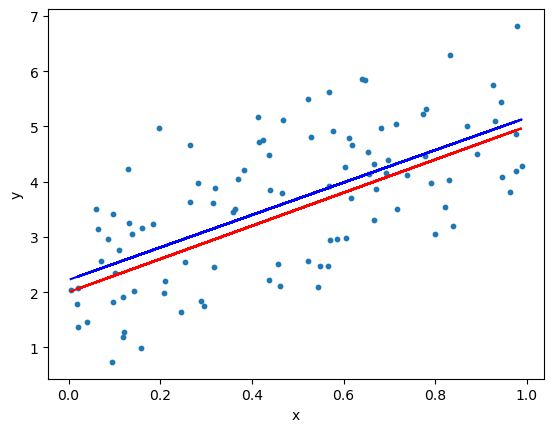

In [35]:
# Graficamos
plt.scatter(x, y, s=10)  # s indica el tamaño de los puntos del scatter.
plt.plot(x, 2+3*x, color='red')
plt.plot(x, y_pred, color='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### Regresion, Numero de predictores y medidas de bondad de ajuste

In [37]:
# Creamos un segundo predictor
x2 = np.random.normal(5,4,100)  # Array de la forma (100, 1) de una distribución normal con media 5 y desvio estandar 4.
X = np.column_stack((x, x2)) # Armamos la matriz con los dos predictores
#print(X)

In [38]:
x_con2 = sm.add_constant(X)
model2 = sm.OLS(y, x_con2)
results2 = model2.fit()
print(results2.summary())
# Estima y predicho
y_pred2 = results2.predict(x_con2)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.416
Method:                 Least Squares   F-statistic:                     36.29
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.72e-12
Time:                        15:37:22   Log-Likelihood:                -140.77
No. Observations:                 100   AIC:                             287.5
Df Residuals:                      97   BIC:                             295.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0742      0.229      9.071      0.0

Ahora armemos un tercer predictor NO relacionado con $Y$, y veamos que pasa.


In [39]:
# Creamos un tercer predictor
x3 = np.random.normal(10,2,100)  # Array de la forma (100, 1) de una distribución normal con media 10 y desvio estandar 2.
X = np.column_stack((x, x2,x3)) # Armamos la matriz con los dos predictores
#print(X)

In [40]:
x_con3 = sm.add_constant(X)
model3 = sm.OLS(y, x_con3)
results3 = model3.fit()
print(results3.summary())
# Estima y predicho
y_pred3 = results3.predict(x_con3)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     24.33
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           8.57e-12
Time:                        15:40:51   Log-Likelihood:                -140.43
No. Observations:                 100   AIC:                             288.9
Df Residuals:                      96   BIC:                             299.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5130      0.587      4.282      0.0

#### Modelo mal especificado

In [41]:
# Creamos un tercer predictor
X_mal = np.column_stack((x2,x3)) # Armamos la matriz con los dos predictores
#print(X)

In [42]:
x_con_mal = sm.add_constant(X_mal)
model4 = sm.OLS(y, x_con_mal)
results4 = model4.fit()
print(results4.summary())
# Estima y predicho
y_pred4 = results4.predict(x_con_mal)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.3344
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.717
Time:                        15:41:56   Log-Likelihood:                -168.36
No. Observations:                 100   AIC:                             342.7
Df Residuals:                      97   BIC:                             350.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9842      0.737      5.403      0.0

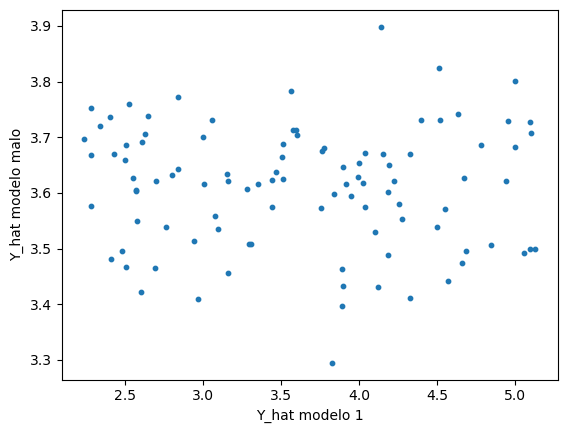

In [44]:
# Graficamos
plt.scatter(y_pred, y_pred4, s=10)  
plt.xlabel('Y_hat modelo 1')
plt.ylabel('Y_hat modelo malo')
plt.show()

#### MSE con datos de entrenamiento (dentro de la muestra)

In [45]:
# Usando MSE de scikit-learn
mse1 = mean_squared_error(y, y_pred)
print(mse1)

# Usando la formula manualmente
mse2 = np.square(np.subtract(y, y_pred)).mean()
print(mse2)

0.9924386487246479
0.9924386487246479


In [46]:
# También podemos ver el RMSE y el MAE
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(rmse)
mae = mean_absolute_error(y, y_pred)
print(mae)

0.9962121504602561
0.849258198323929


In [47]:
import pandas as pd

In [48]:
# tenemos las predicciones de los 3 modelos
y_pred = [y_pred2, y_pred3, y_pred4]

# Creamos una lista para armar los resultados de error de pronóstico de Y
resultados = []

# Itera sobre los modelos
for i, y_pred in enumerate(y_pred):
    
    # Calcula las medidas de error
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    
    # Guarda los resultados
    resultados.append({
        'Modelo': f'Modelo {i+2}',
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae
    })

# Crea un DataFrame con los resultados
df_resultados = pd.DataFrame(resultados)

# Muestra la tabla con los resultados
print(df_resultados)

     Modelo       MSE      RMSE       MAE
0  Modelo 2  0.977814  0.988845  0.839667
1  Modelo 3  0.971142  0.985466  0.837711
2  Modelo 4  1.697675  1.302948  1.079730


### MSE con datos de testeo (afuera de la muestra)


In [49]:
# Generamos un nuevo dataset aleatorio para testear nuestor modelo estimado
np.random.seed(0)
x_new = np.random.rand(10)  # Array de la forma (10, 1) con nros aleatorios entre [0, 1) de una distribución uniforme
epsilon_new = np.random.normal(0,1,10) # error no sistematico

y_new = 2 + 3*x_new + epsilon_new
print("x:\n", x_new)
print("y:\n", y_new)
print("epsilon:\n", epsilon_new)

x:
 [0.5488135  0.71518937 0.60276338 0.54488318 0.4236548  0.64589411
 0.43758721 0.891773   0.96366276 0.38344152]
y:
 [3.79048408 5.59984161 4.56932785 3.75632457 3.71482763 4.27135667
 4.80684071 4.47016074 5.20405598 2.29622882]
epsilon:
 [ 0.14404357  1.45427351  0.76103773  0.12167502  0.44386323  0.33367433
  1.49407907 -0.20515826  0.3130677  -0.85409574]


In [50]:
# Nueva Predeccion las y
x_new_con = sm.add_constant(x_new) # agregamos constante
y_pred_new = results.predict(x_new_con)

print("Forma de y_pred:", y_pred_new.shape)
print("Dimensiones de y:", y_pred_new.ndim)

Forma de y_pred: (10,)
Dimensiones de y: 1


Ahora si veamos la predicción afuera de la muestra



In [51]:
# Usando MSE testeo de scikit-learn
mse_test = mean_squared_error(y_new, y_pred_new)
print(mse_test)

0.5011588948294403


In [52]:
# También podemos ver el RMSE y el MAE
rmse_test = np.sqrt(mean_squared_error(y_new, y_pred_new))
print(rmse_test)
mae_test = mean_absolute_error(y_new, y_pred_new)
print(mae_test)

0.7079257692932504
0.5238771033262469
